In [149]:
import pandas as pd
import numpy as np
from seaborn import load_dataset
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score,r2_score
from keras.models import Sequential, Model
from keras.layers import Dense, BatchNormalization, Dropout
from keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [150]:
Data = pd.read_csv(r'C:\Users\saife\Downloads\bengaluru_house_prices.csv')
Data.head(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [151]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [152]:
summery = Data.describe()
print(summery)

               bath       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000     72.000000
75%        3.000000      2.000000    120.000000
max       40.000000      3.000000   3600.000000


<Axes: >

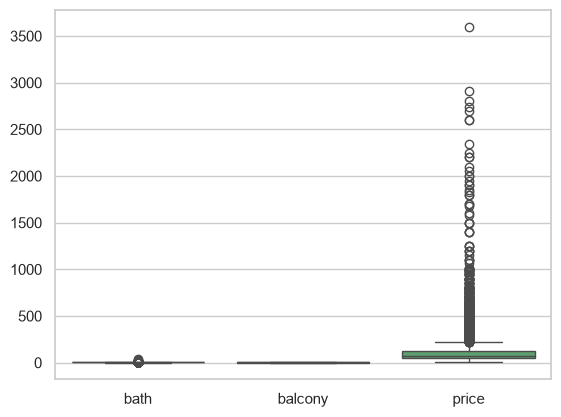

In [153]:
sns.set(style="whitegrid",    )
sns.boxplot(data=Data)

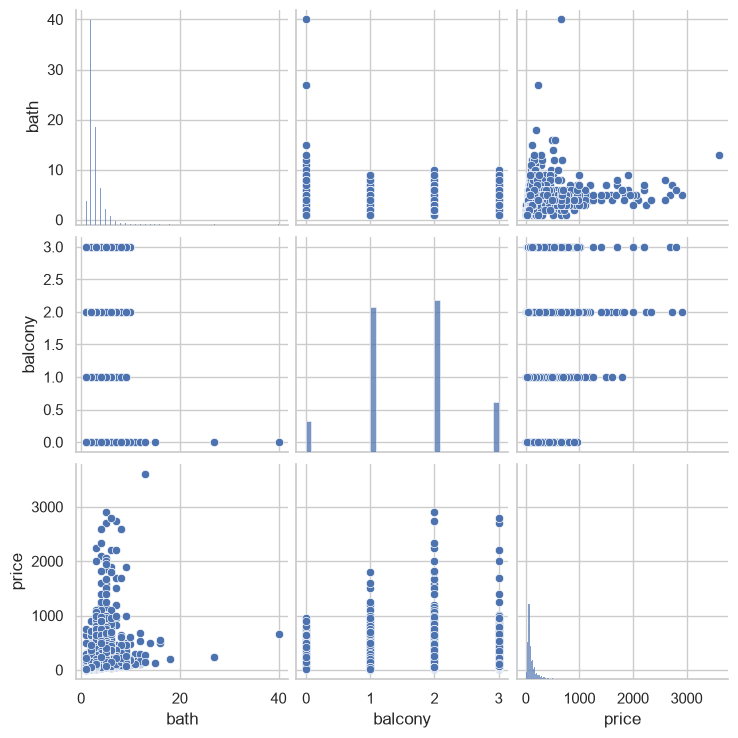

In [154]:
sns.pairplot(data=Data)

In [155]:
import re

def parse_size(x):
    if pd.isna(x):
        return np.nan
    match = re.search(r'\d+', str(x))
    return int(match.group()) if match else np.nan

Data['BHK'] = Data['size'].apply(parse_size)

UNIT_TO_SQFT = {
    'Sq. Meter': 10.7639,
    'Sq. Yards': 9.0,
    'Perch': 272.25,
    'Acres': 43560.0,
    'Guntha': 1089.0,
    'Cents': 435.56,
    'Grounds': 2400.35,}

In [156]:
def parse_sqft(x):
    x = str(x).strip()
    # range like "2100 - 2850" -> average
    if '-' in x:
        parts = x.split('-')
        try:
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except ValueError:
            return np.nan
    # unit suffix like "34.46Sq. Meter" or "30Acres"
    for unit, factor in UNIT_TO_SQFT.items():
        if unit in x:
            num = re.search(r'[\d.]+', x)
            return float(num.group()) * factor if num else np.nan
    # plain number
    try:
        return float(x)
    except ValueError:
        return np.nan

Data['total_sqft'] = Data['total_sqft'].apply(parse_sqft)


In [157]:
Data['location'] = Data['location'].astype(str).str.strip()
location_counts = Data['location'].value_counts()
rare_locations = location_counts[location_counts <= 10].index
Data['location'] = Data['location'].apply(lambda x: 'other' if x in rare_locations else x)

In [158]:
Data = Data.drop(columns=['society', 'size'])
Data = Data.dropna(subset=['total_sqft', 'BHK', 'bath', 'price'])
Data['balcony'] = Data['balcony'].fillna(Data['balcony'].median())
Data['price_per_sqft'] = Data['price'] * 100000 / Data['total_sqft']

In [159]:
Data = pd.get_dummies(Data, columns=['area_type', 'availability', 'location'], drop_first=True)

In [160]:
Data = Data.drop(columns=['price_per_sqft'])
Data = Data.astype('float64')


In [161]:
print(Data.shape)
print(Data.head())


(13247, 328)
   total_sqft  bath  balcony   price  BHK  area_type_Carpet  Area  \
0      1056.0   2.0      1.0   39.07  2.0                     0.0   
1      2600.0   5.0      3.0  120.00  4.0                     0.0   
2      1440.0   2.0      3.0   62.00  3.0                     0.0   
3      1521.0   3.0      1.0   95.00  3.0                     0.0   
4      1200.0   2.0      1.0   51.00  2.0                     0.0   

   area_type_Plot  Area  area_type_Super built-up  Area  availability_14-Nov  \
0                   0.0                             1.0                  0.0   
1                   1.0                             0.0                  0.0   
2                   0.0                             0.0                  0.0   
3                   0.0                             1.0                  0.0   
4                   0.0                             1.0                  0.0   

   availability_15-Aug  ...  location_Vishveshwarya Layout  \
0                  0.0  ...  

In [162]:
scaler = MinMaxScaler()
DataScaled = scaler.fit_transform(Data)
DataScaled = pd.DataFrame(DataScaled, columns=Data.columns)

In [164]:
cols = [c for c in Data.columns if c != 'price'] + ['price']
Data = Data[cols]

print(Data.shape)
print(Data.head())
n_features = DataScaled.shape[1] - 1


(13247, 328)
   total_sqft  bath  balcony  BHK  area_type_Carpet  Area  \
0      1056.0   2.0      1.0  2.0                     0.0   
1      2600.0   5.0      3.0  4.0                     0.0   
2      1440.0   2.0      3.0  3.0                     0.0   
3      1521.0   3.0      1.0  3.0                     0.0   
4      1200.0   2.0      1.0  2.0                     0.0   

   area_type_Plot  Area  area_type_Super built-up  Area  availability_14-Nov  \
0                   0.0                             1.0                  0.0   
1                   1.0                             0.0                  0.0   
2                   0.0                             0.0                  0.0   
3                   0.0                             1.0                  0.0   
4                   0.0                             1.0                  0.0   

   availability_15-Aug  availability_15-Dec  ...  location_Vishwapriya Layout  \
0                  0.0                  0.0  ...          

In [125]:
X = DataScaled.iloc[:, :-1]
Y = DataScaled.iloc[:, -1]

In [126]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=1
)

In [165]:

model = Sequential()
model.add(Input(shape=(n_features,)))
model.add(Dense(20, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 20)             │         6,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,891 (26.92 KB)

 Trainable params: 6,891 (26.92 KB)

 Non-trainable params: 0 (0.00 B)

In [167]:
history = model.fit(
    X_train, Y_train,
    epochs=100, verbose=1,
    validation_split=0.2, batch_size=128
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1662 - mae: 0.2866 - val_loss: 0.1308 - val_mae: 0.2715
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0832 - mae: 0.2078 - val_loss: 0.0368 - val_mae: 0.1344
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0159 - mae: 0.0748 - val_loss: 0.0062 - val_mae: 0.0410
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - mae: 0.0276 - val_loss: 0.0022 - val_mae: 0.0229
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019 - mae: 0.0190 - val_loss: 0.0012 - val_mae: 0.0186
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014 - mae: 0.0146 - val_loss: 8.0967e-04 - val_mae: 0.0147
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011 - mae: 0.0125 - val_loss: 6.4840e-04 - val_mae: 0.0132
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010 - mae: 0.0114 - val_loss: 5.5027e-04 - val_mae: 0.0124
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

In [168]:

y_predKM = model.predict(X_test)
print('Coefficient of determination of Keras Model (with outliers)')
print(r2_score(Y_test, y_predKM))

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Coefficient of determination of Keras Model (with outliers)
0.9863622823907607


In [77]:
Data = pd.get_dummies( Data, columns=['area_type', 'availability', 'location'], drop_first=True)

In [78]:
print(Data.shape)
print(Data.head())

(13247, 1389)
  total_sqft  bath  balcony   price  area_type_Carpet  Area  \
0       1056   2.0      1.0   39.07                   False   
1       2600   5.0      3.0  120.00                   False   
2       1440   2.0      3.0   62.00                   False   
3       1521   3.0      1.0   95.00                   False   
4       1200   2.0      1.0   51.00                   False   

   area_type_Plot  Area  area_type_Super built-up  Area  availability_14-Nov  \
0                 False                            True                False   
1                  True                           False                False   
2                 False                           False                False   
3                 False                            True                False   
4                 False                            True                False   

   availability_15-Aug  availability_15-Dec  ...  location_rr nagar  \
0                False                False  ...       

In [79]:

scalar=MinMaxScaler()
Data_scaled=scalar.fit_transform(Data)
Data_scaled=pd.DataFrame(Data_scaled,columns=Data.columns)


ValueError: could not convert string to float: '34.46Sq. Meter'